In [107]:
import torch
from torch import nn
import numpy as np
import torchvision

In [2]:
from pathlib import Path
data_path = Path('data/')
image_path = data_path / 'desert101'

In [3]:
image_path

PosixPath('data/desert101')

In [4]:
import os
def chech_data(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"# of directories: {len(dirnames)} and {len(filenames)} images in '{dirpath}'.")

In [5]:
chech_data(image_path)

# of directories: 2 and 1 images in 'data/desert101'.
# of directories: 4 and 1 images in 'data/desert101/test'.
# of directories: 0 and 20 images in 'data/desert101/test/cup_cakes'.
# of directories: 0 and 20 images in 'data/desert101/test/donuts'.
# of directories: 0 and 20 images in 'data/desert101/test/cannoli'.
# of directories: 0 and 20 images in 'data/desert101/test/baklava'.
# of directories: 4 and 1 images in 'data/desert101/train'.
# of directories: 0 and 80 images in 'data/desert101/train/cup_cakes'.
# of directories: 0 and 80 images in 'data/desert101/train/donuts'.
# of directories: 0 and 80 images in 'data/desert101/train/cannoli'.
# of directories: 0 and 80 images in 'data/desert101/train/baklava'.


In [6]:
train_dir = image_path / 'train'
test_dir = image_path / 'test'

In [7]:
train_dir

PosixPath('data/desert101/train')

In [8]:
test_dir

PosixPath('data/desert101/test')

In [9]:
from PIL import Image
import random

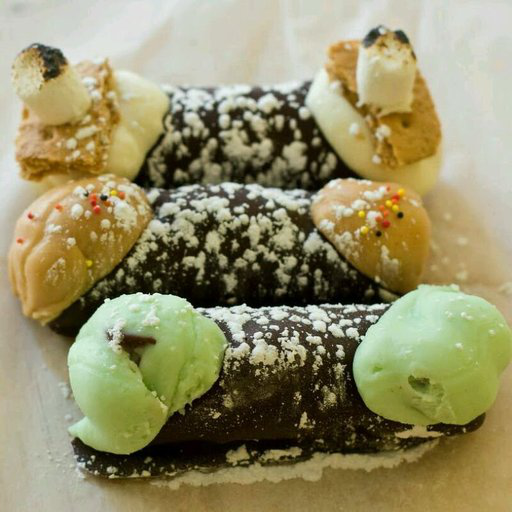

In [10]:
#random.seed(42)
# print(list(image_path.glob('**/*.jpg'))) # Klasör derinliği kaç olursa olsun tüm .jpg dosyalarını toplar
image_path_list = list(image_path.glob('*/*/*.jpg'))
random_image = random.choice(image_path_list)
img = Image.open(random_image)
img

In [11]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [12]:
#[PIL üzerinde çalışan transformlar]  →  ToTensor()  →  [tensör üzerinde çalışan transformlar, örn. Normalize]
data_transforms = transforms.Compose([
    transforms.Resize(size = (64,64)),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor()
])

In [13]:
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transforms,
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                  transform=data_transforms,
                                  target_transform=None)

In [14]:
train_data

Dataset ImageFolder
    Number of datapoints: 316
    Root location: data/desert101/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )

In [15]:
test_data

Dataset ImageFolder
    Number of datapoints: 77
    Root location: data/desert101/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )

In [16]:
class_names = train_data.classes # hepsi ayri klasorlerde oldugu icin direkt alabiliyoruz

In [17]:
class_names

['baklava', 'cannoli', 'cup_cakes', 'donuts']

In [18]:
len(train_data), len(test_data), len(class_names)

(316, 77, 4)

In [19]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

In [20]:
NUM_WORKERS

12

In [70]:
train_dataloader = DataLoader(dataset=train_data,
                               batch_size=BATCH_SIZE,
                               shuffle=True,
                               num_workers=NUM_WORKERS)

test_dataloader = DataLoader(dataset=test_data,
                               batch_size=BATCH_SIZE,
                               shuffle=False,
                               num_workers=NUM_WORKERS)

Text(0.5, 1.0, 'baklava')

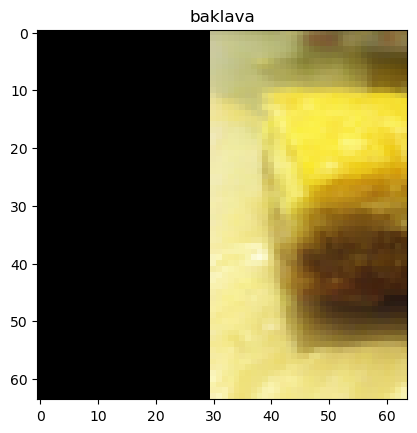

In [22]:
import matplotlib.pyplot as plt
plt.imshow(train_data_loader.dataset[3][0].permute(1,2,0))
plt.title(class_names[train_data_loader.dataset[3][1]])

In [23]:
class DesertClassifier(nn.Module):
    def __init__(self, input_shape:int, hidden_units:int, output_shape:int) -> None: #bu fonksiyon bir değer döndürmez
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                          stride=2)# default stride value is same as kernel_size
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 16 * 16,out_features=output_shape)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x


In [24]:
torch.manual_seed(42)
model_0 = DesertClassifier(input_shape=3,
                          hidden_units=32,
                          output_shape=len(class_names))

In [25]:
len(class_names)

4

In [26]:
!pip install torchinfo


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [27]:
from torchinfo import summary

summary(model_0, input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
DesertClassifier                         [1, 4]                    --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─ReLU: 2-2                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 64, 64]           9,248
│    └─ReLU: 2-4                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-7                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-9                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 32, 16, 16]           --
├─Seq

In [73]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    model.train()

    train_loss, train_acc = 0, 0

    for batch, (X,y) in enumerate(dataloader):
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.softmax(y_pred, dim=1).argmax(dim=1)
        train_acc += ((y_pred_class == y).sum().item()) / len(y) 
        
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [75]:
def test_step(model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module):
    model.eval()

    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for batch, (X,y) in enumerate(dataloader):
            test_pred = model(X)
            test_loss = loss_fn(test_pred, y)
            test_loss += test_loss.item()
    
            test_pred_class = torch.softmax(test_pred, dim=1).argmax(dim=1)
            test_acc += ((test_pred_class == y).sum().item()) / len(y)
        
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc    

In [77]:
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int = 5):
    results = {
        'train_loss' : [],
        'train_acc' : [],
        'test_loss' : [],
        'test_acc' : [],
    }
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn)

        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    return results

In [83]:
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

EPOCHS = 10
model_0 = DesertClassifier(input_shape=3,
                          hidden_units=32,
                          output_shape=len(class_names))
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_0.parameters(), lr = 0.001)

model_0_results = train(model = model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader= test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=EPOCHS)

Epoch: 1 | train_loss: 1.3941 | train_acc: 0.2205 | test_loss: 0.9173 | test_acc: 0.2083
Epoch: 2 | train_loss: 1.3845 | train_acc: 0.2509 | test_loss: 0.9181 | test_acc: 0.2083
Epoch: 3 | train_loss: 1.3633 | train_acc: 0.3321 | test_loss: 0.9041 | test_acc: 0.3117
Epoch: 4 | train_loss: 1.3515 | train_acc: 0.3312 | test_loss: 0.9373 | test_acc: 0.2756
Epoch: 5 | train_loss: 1.3270 | train_acc: 0.3379 | test_loss: 0.8388 | test_acc: 0.4151
Epoch: 6 | train_loss: 1.3139 | train_acc: 0.3585 | test_loss: 0.9084 | test_acc: 0.4046
Epoch: 7 | train_loss: 1.2872 | train_acc: 0.3799 | test_loss: 0.9653 | test_acc: 0.3429
Epoch: 8 | train_loss: 1.2551 | train_acc: 0.4201 | test_loss: 1.0053 | test_acc: 0.2917
Epoch: 9 | train_loss: 1.2947 | train_acc: 0.4165 | test_loss: 0.8674 | test_acc: 0.4567
Epoch: 10 | train_loss: 1.1895 | train_acc: 0.4554 | test_loss: 1.0004 | test_acc: 0.3998


In [84]:
model_0_results

{'train_loss': [1.394090437889099,
  1.3845340251922607,
  1.3633271217346192,
  1.35146324634552,
  1.3270089507102967,
  1.3139410138130188,
  1.2872088551521301,
  1.2551357865333557,
  1.2947183489799499,
  1.1895412445068358],
 'train_acc': [0.22053571428571428,
  0.25089285714285714,
  0.33214285714285713,
  0.33125,
  0.33794642857142854,
  0.35848214285714286,
  0.37991071428571427,
  0.42008928571428567,
  0.4165178571428571,
  0.4553571428571429],
 'test_loss': [0.917273223400116,
  0.9180566668510437,
  0.9041476845741272,
  0.9372681975364685,
  0.8388025164604187,
  0.9084475636482239,
  0.9653251767158508,
  1.0053430795669556,
  0.8674421906471252,
  1.0003845691680908],
 'test_acc': [0.20833333333333334,
  0.20833333333333334,
  0.31169871794871795,
  0.2756410256410256,
  0.4150641025641026,
  0.4046474358974359,
  0.3429487179487179,
  0.2916666666666667,
  0.4567307692307692,
  0.3998397435897436]}

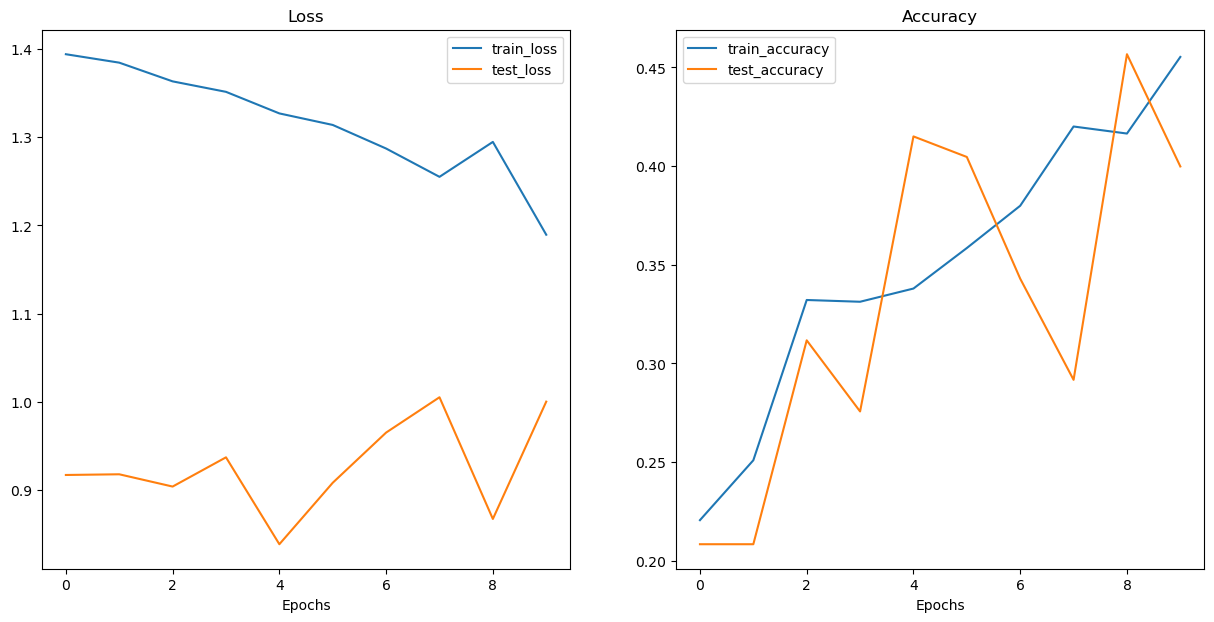

In [87]:
import matplotlib.pyplot as plt

def plot_loss_curves(results):
    loss = results['train_loss']
    test_loss = results['test_loss']
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    epochs = range(len(results['train_loss']))

    # Setup a plot 
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()
    
plot_loss_curves(results = model_0_results)

In [89]:
def make_predictions(model: torch.nn.Module, data: list):
    """
    data: [img_tensor, img_tensor, ...]  # her biri [C, H, W]
    return: [N, num_classes] olasılık tensörü
    """
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # [C, H, W] -> [1, C, H, W]
            sample = sample.unsqueeze(0)

            # Logits al
            pred_logit = model(sample)    # shape: [1, num_classes]

            # Softmax ile olasılığa çevir
            prob = torch.softmax(pred_logit, dim=1)  # [1, num_classes]

            # Batch boyutunu sıkıştır
            pred_probs.append(prob.squeeze(0))       # [num_classes]

    # Hepsini birleştir → [N, num_classes]
    return torch.stack(pred_probs)
    
def show_random_predictions(model, dataset, class_names, n=9):
    model.eval()
    
    plt.figure(figsize=(4, 4))

    # random 9 index seç
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # modele uygun hale getir
            img_input = img.unsqueeze(0)  
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # görseli çizmek için permute
            img_show = img.permute(1, 2, 0)

            # doğru mu yanlış mı?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # subplot
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

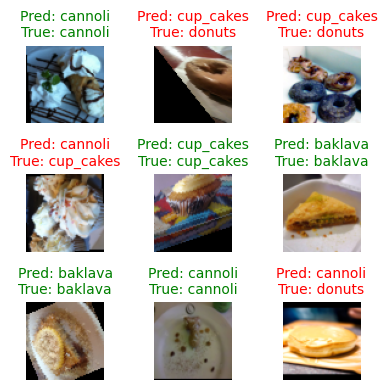

In [93]:
show_random_predictions(model_0, test_data, class_names)

In [125]:
online_image_path = data_path / 'baklava-online.jpeg'

In [127]:
online_image_path

PosixPath('data/baklava-online.jpeg')

In [137]:
single_image = torchvision.io.read_image(path=str(online_image_path))

In [139]:
single_image

tensor([[[ 63,  64,  65,  ..., 136, 141, 143],
         [ 58,  59,  61,  ..., 119, 123, 124],
         [ 51,  53,  56,  ..., 106, 109, 110],
         ...,
         [101,  92,  82,  ..., 108,  86,  89],
         [ 88,  81,  73,  ..., 134, 113, 116],
         [ 74,  68,  63,  ..., 156, 136, 139]],

        [[ 66,  67,  68,  ..., 140, 145, 147],
         [ 61,  62,  64,  ..., 123, 127, 128],
         [ 54,  56,  59,  ..., 110, 113, 114],
         ...,
         [100,  91,  81,  ..., 113,  91,  94],
         [ 87,  80,  72,  ..., 139, 118, 121],
         [ 73,  67,  62,  ..., 161, 141, 144]],

        [[ 73,  74,  75,  ..., 151, 156, 158],
         [ 68,  69,  71,  ..., 134, 138, 139],
         [ 61,  63,  66,  ..., 121, 124, 125],
         ...,
         [105,  96,  86,  ..., 119,  97, 100],
         [ 92,  85,  77,  ..., 145, 124, 127],
         [ 78,  72,  67,  ..., 167, 147, 150]]], dtype=torch.uint8)

In [141]:
single_image = torchvision.io.read_image(path=str(online_image_path)).type(torch.float32)

In [143]:
single_image

tensor([[[ 63.,  64.,  65.,  ..., 136., 141., 143.],
         [ 58.,  59.,  61.,  ..., 119., 123., 124.],
         [ 51.,  53.,  56.,  ..., 106., 109., 110.],
         ...,
         [101.,  92.,  82.,  ..., 108.,  86.,  89.],
         [ 88.,  81.,  73.,  ..., 134., 113., 116.],
         [ 74.,  68.,  63.,  ..., 156., 136., 139.]],

        [[ 66.,  67.,  68.,  ..., 140., 145., 147.],
         [ 61.,  62.,  64.,  ..., 123., 127., 128.],
         [ 54.,  56.,  59.,  ..., 110., 113., 114.],
         ...,
         [100.,  91.,  81.,  ..., 113.,  91.,  94.],
         [ 87.,  80.,  72.,  ..., 139., 118., 121.],
         [ 73.,  67.,  62.,  ..., 161., 141., 144.]],

        [[ 73.,  74.,  75.,  ..., 151., 156., 158.],
         [ 68.,  69.,  71.,  ..., 134., 138., 139.],
         [ 61.,  63.,  66.,  ..., 121., 124., 125.],
         ...,
         [105.,  96.,  86.,  ..., 119.,  97., 100.],
         [ 92.,  85.,  77.,  ..., 145., 124., 127.],
         [ 78.,  72.,  67.,  ..., 167., 147., 150.]]]

In [145]:
single_image = single_image / 255

In [147]:
single_image

tensor([[[0.2471, 0.2510, 0.2549,  ..., 0.5333, 0.5529, 0.5608],
         [0.2275, 0.2314, 0.2392,  ..., 0.4667, 0.4824, 0.4863],
         [0.2000, 0.2078, 0.2196,  ..., 0.4157, 0.4275, 0.4314],
         ...,
         [0.3961, 0.3608, 0.3216,  ..., 0.4235, 0.3373, 0.3490],
         [0.3451, 0.3176, 0.2863,  ..., 0.5255, 0.4431, 0.4549],
         [0.2902, 0.2667, 0.2471,  ..., 0.6118, 0.5333, 0.5451]],

        [[0.2588, 0.2627, 0.2667,  ..., 0.5490, 0.5686, 0.5765],
         [0.2392, 0.2431, 0.2510,  ..., 0.4824, 0.4980, 0.5020],
         [0.2118, 0.2196, 0.2314,  ..., 0.4314, 0.4431, 0.4471],
         ...,
         [0.3922, 0.3569, 0.3176,  ..., 0.4431, 0.3569, 0.3686],
         [0.3412, 0.3137, 0.2824,  ..., 0.5451, 0.4627, 0.4745],
         [0.2863, 0.2627, 0.2431,  ..., 0.6314, 0.5529, 0.5647]],

        [[0.2863, 0.2902, 0.2941,  ..., 0.5922, 0.6118, 0.6196],
         [0.2667, 0.2706, 0.2784,  ..., 0.5255, 0.5412, 0.5451],
         [0.2392, 0.2471, 0.2588,  ..., 0.4745, 0.4863, 0.

Text(0.5, 1.0, 'torch.Size([3, 1333, 2000])')

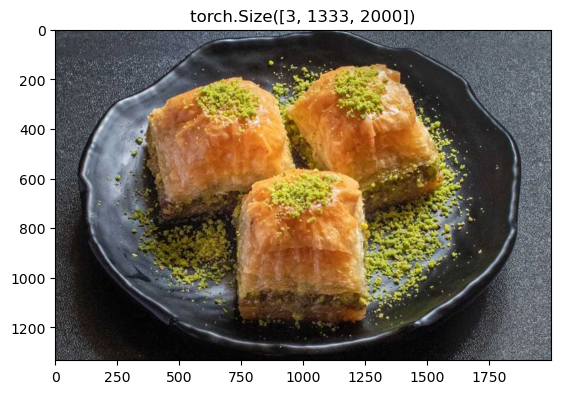

In [154]:
plt.imshow(single_image.permute(1,2,0))
plt.title(single_image.shape)

In [156]:
single_image_transform = transforms.Compose({
    transforms.Resize(size = (64,64))
})

single_image = single_image_transform(single_image)

In [158]:
single_image.shape

torch.Size([3, 64, 64])

Text(0.5, 1.0, 'torch.Size([3, 64, 64])')

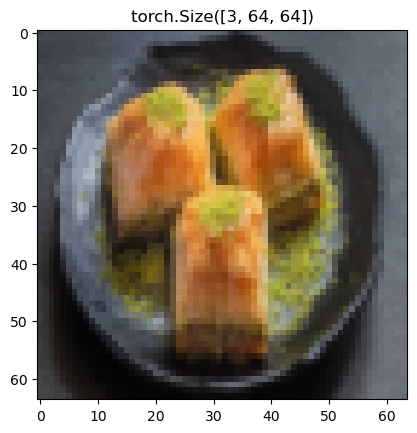

In [160]:
plt.imshow(single_image.permute(1,2,0))
plt.title(single_image.shape)

In [178]:
single_image.unsqueeze_(dim=0).shape

torch.Size([1, 3, 64, 64])

In [182]:
single_image.shape

torch.Size([1, 3, 64, 64])

In [184]:
model_0.eval()
with torch.inference_mode():
    logits = model_0(single_image)
    probs = torch.softmax(logits, dim=1)
    pred_idx = probs.argmax(dim=1).item()

print("Predicted class:", class_names[pred_idx])

Predicted class: baklava
